In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import tensorflow as tf
import kagglehub
from PIL import Image
import shutil
from tensorflow.keras import applications, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
# Download latest version
path = kagglehub.dataset_download("ninadaithal/imagesoasis")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/imagesoasis


In [2]:
import shutil
import os

# Path to original data
input_data_path = "/kaggle/input/imagesoasis"

# Path to writable directory
writable_data_path = "/kaggle/working/imagesoasis"

# If it doesn't already exist, copy the data
if not os.path.exists(writable_data_path):
    shutil.copytree(input_data_path, writable_data_path)

# Now use the writable path
dataset_path = writable_data_path



In [3]:
files = os.listdir(path)
print(files)

['Data']


In [4]:
dataset_path = "/kaggle/working/imagesoasis/Data"
subdirs = os.listdir(dataset_path)

print("Subdirectories in data folder:", subdirs)

Subdirectories in data folder: ['Mild Dementia', 'Moderate Dementia', 'Very mild Dementia', 'Non Demented']


In [5]:
# Print first few images from each category
for category in os.listdir(dataset_path):
    category_path = os.path.join(dataset_path, category)
    if os.path.isdir(category_path):  # Ensure it's a folder
        print(f"Category: {category}")
        print(os.listdir(category_path)[:5])  # Show first 5 files
        print("-" * 40)

Category: Mild Dementia
['OAS1_0052_MR1_mpr-2_135.jpg', 'OAS1_0223_MR1_mpr-3_117.jpg', 'OAS1_0184_MR1_mpr-3_109.jpg', 'OAS1_0137_MR1_mpr-2_120.jpg', 'OAS1_0278_MR1_mpr-4_139.jpg']
----------------------------------------
Category: Moderate Dementia
['OAS1_0351_MR1_mpr-2_109.jpg', 'OAS1_0308_MR1_mpr-4_100.jpg', 'OAS1_0308_MR1_mpr-3_147.jpg', 'OAS1_0308_MR1_mpr-4_146.jpg', 'OAS1_0351_MR1_mpr-3_155.jpg']
----------------------------------------
Category: Very mild Dementia
['OAS1_0339_MR1_mpr-1_125.jpg', 'OAS1_0286_MR1_mpr-2_110.jpg', 'OAS1_0290_MR1_mpr-3_112.jpg', 'OAS1_0304_MR1_mpr-2_114.jpg', 'OAS1_0374_MR1_mpr-3_151.jpg']
----------------------------------------
Category: Non Demented
['OAS1_0277_MR1_mpr-1_152.jpg', 'OAS1_0057_MR1_mpr-3_119.jpg', 'OAS1_0160_MR1_mpr-2_106.jpg', 'OAS1_0239_MR1_mpr-4_127.jpg', 'OAS1_0062_MR1_mpr-1_141.jpg']
----------------------------------------


In [6]:
import os

if os.path.exists(dataset_path):
    print("Dataset path exists. Contents:")
    print(os.listdir(dataset_path))
else:
    print("Dataset path does NOT exist!")


Dataset path exists. Contents:
['Mild Dementia', 'Moderate Dementia', 'Very mild Dementia', 'Non Demented']


Category: Non Demented has 67222 images.
Category: Very mild Dementia has 13725 images.
Category: Mild Dementia has 5002 images.
Category: Moderate Dementia has 488 images.


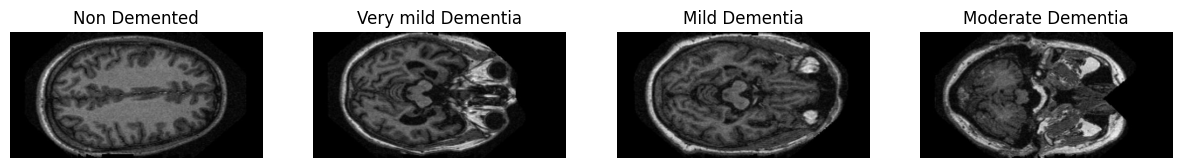

In [7]:
# Class labels
categories = ["Non Demented", "Very mild Dementia", "Mild Dementia", "Moderate Dementia"]

# Plot images
fig, axes = plt.subplots(1, 4, figsize=(15, 5))


for i, category in enumerate(categories):
    category_path = os.path.join(dataset_path, category)
    sample_image = os.path.join(category_path, os.listdir(category_path)[0])  # Pick first image

    # Load image in grayscale
    image = cv2.imread(sample_image, cv2.IMREAD_GRAYSCALE)

    # Display image
    axes[i].imshow(image, cmap="gray")
    axes[i].set_title(category)
    axes[i].axis("off")
    image_files = os.listdir(category_path)
    print(f"Category: {category} has {len(image_files)} images.")

plt.show()

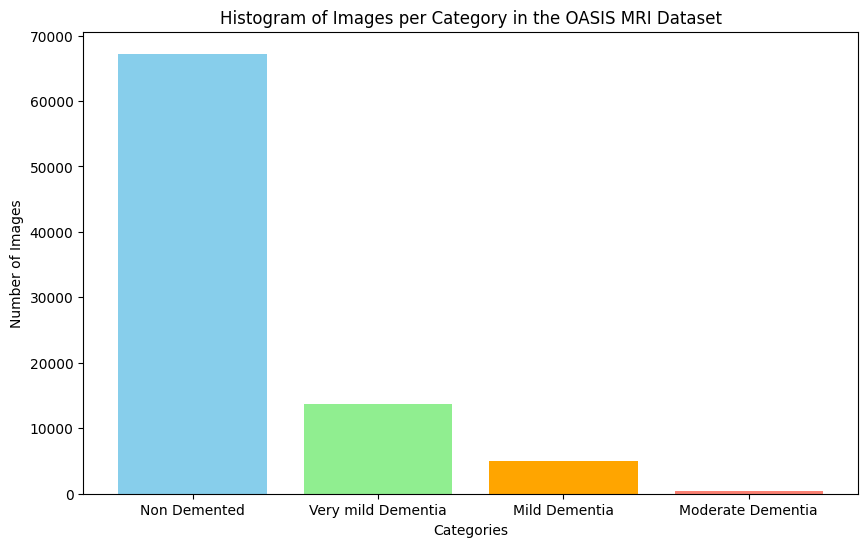

In [8]:
image_counts = [67222, 13725, 5002, 488]

# Plotting the histogram
plt.figure(figsize=(10, 6))
plt.bar(categories, image_counts, color=['skyblue', 'lightgreen', 'orange', 'salmon'])

# Adding labels and title
plt.xlabel('Categories')
plt.ylabel('Number of Images')
plt.title('Histogram of Images per Category in the OASIS MRI Dataset')

# Displaying the plot
plt.show()

In [9]:

# Get a list of images in the directory
non_demented_path = os.path.join(dataset_path, categories[0])
very_mild_path = os.path.join(dataset_path, categories[1])
mild_path = os.path.join(dataset_path, categories[2])
moderate_path = os.path.join(dataset_path, categories[3])
category_path = non_demented_path
image_files = os.listdir(category_path)
# Open the first image and check its size
image_path = os.path.join(category_path, image_files[0])  # Choose the first image in the list
image = Image.open(image_path)

# Get the size (width, height)
width, height = image.size

# Print the size of the first image
print(f"Size of the first image: {width} x {height}")

Size of the first image: 496 x 248


In [10]:
mild_path = os.path.join(dataset_path, "Mild Dementia")
moderate_path = os.path.join(dataset_path, "Moderate Dementia")
merged_path = os.path.join(dataset_path, "Mild_Moderate")

# Create merged folder if it doesn't exist
if not os.path.exists(merged_path):
    os.makedirs(merged_path)

# Move images
for category_path in [mild_path, moderate_path]:
    for file in os.listdir(category_path):
        shutil.move(os.path.join(category_path, file), merged_path)

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

augmentor = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.2
)

def augment_and_save(folder, num_augmented=2):
    images = os.listdir(folder)
    for img_name in images:
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
        img = img.reshape((1,) + img.shape)  # Reshape for ImageDataGenerator

        save_prefix = img_name.split('.')[0]
        i = 0
        for batch in augmentor.flow(img, batch_size=1, save_to_dir=folder, save_prefix=save_prefix, save_format="jpg"):
            i += 1
            if i >= num_augmented:
                break

for category in ["Very mild Dementia", "Mild_Moderate"]:
    augment_and_save(os.path.join(dataset_path, category))


In [12]:
import os
import matplotlib.pyplot as plt


# Define the categories after merging "Mild" and "Moderate" into one
categories = ["Non Demented", "Very mild Dementia", "Mild_Moderate"]

# Count images in each category
data_counts = {}

for category in categories:
    category_path = os.path.join(dataset_path, category)
    num_images = len(os.listdir(category_path))
    data_counts[category] = num_images

# Print counts
for category, count in data_counts.items():
    print(f"{category}: {count} images")


Non Demented: 67222 images
Very mild Dementia: 41174 images
Mild_Moderate: 16470 images


In [ ]:
import os
import cv2

def resize_images(folder, target_size=(224, 224)):
    """Resizes all images in the given folder to the target size."""
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)

        # Read the image
        img = cv2.imread(img_path)
        if img is None:  # Skip corrupted images
            continue

        # Resize and overwrite the image
        img_resized = cv2.resize(img, target_size)
        cv2.imwrite(img_path, img_resized)

# Resize images in the original dataset before splitting
for category in ["Non Demented", "Very mild Dementia", "Mild_Moderate"]:
    resize_images(os.path.join(dataset_path, category))

print("Resizing completed!")


Resizing completed!


In [ ]:
import os
import shutil
import numpy as np
from sklearn.model_selection import train_test_split

# Define paths
output_path = "/root/split_data"  # New directory for split data

# Ensure output directories exist
for split in ["Train", "Validation", "Test"]:
    for category in ["Non Demented", "Very mild Dementia", "Mild_Moderate"]:
        os.makedirs(os.path.join(output_path, split, category), exist_ok=True)

# Function to split and move images using percentages
def split_data(category, train_ratio=0.70, val_ratio=0.15, test_ratio=0.15):
    category_path = os.path.join(dataset_path, category)
    images = np.array(os.listdir(category_path))

    # Split into train, validation, and test using percentages
    train_images, temp_images = train_test_split(images, train_size=train_ratio, random_state=42)
    val_images, test_images = train_test_split(temp_images, test_size=test_ratio/(val_ratio + test_ratio), random_state=42)

    # Move files to respective folders
    for img in train_images:
        shutil.move(os.path.join(category_path, img), os.path.join(output_path, "Train", category, img))
    for img in val_images:
        shutil.move(os.path.join(category_path, img), os.path.join(output_path, "Validation", category, img))
    for img in test_images:
        shutil.move(os.path.join(category_path, img), os.path.join(output_path, "Test", category, img))

# Perform the split for each category
for category in ["Non Demented", "Very mild Dementia", "Mild_Moderate"]:
    split_data(category)

print("Data splitting completed successfully!")


Data splitting completed successfully!


In [ ]:
# Count images in each split
split_counts = {"Train": {}, "Validation": {}, "Test": {}, "Total": {}}

# Iterate over each split and count images
for split in ["Train", "Validation", "Test"]:
    for category in categories:
        folder_path = os.path.join(output_path, split, category)
        num_images = len(os.listdir(folder_path))
        split_counts[split][category] = num_images

# Calculate total per category
for category in categories:
    split_counts["Total"][category] = sum(split_counts[split][category] for split in ["Train", "Validation", "Test"])

# Print results
print("\nImage distribution after split:\n")
for split in ["Train", "Validation", "Test"]:
    print(f"{split}:")
    for category in categories:
        total = split_counts["Total"][category]
        count = split_counts[split][category]
        percentage = (count / total) * 100
        print(f"  {category}: {count} images ({percentage:.2f}%)")
    print()

# Sanity check
train_total = sum(split_counts["Train"].values())
val_total = sum(split_counts["Validation"].values())
test_total = sum(split_counts["Test"].values())

total_images = train_total + val_total + test_total
print(f"Total images: {total_images}")
print(f"Train: {train_total} ({(train_total / total_images) * 100:.2f}%)")
print(f"Validation: {val_total} ({(val_total / total_images) * 100:.2f}%)")
print(f"Test: {test_total} ({(test_total / total_images) * 100:.2f}%)")


Image distribution after split:

Train:
  Non Demented: 47055 images (70.00%)
  Very mild Dementia: 28821 images (70.00%)
  Mild_Moderate: 11529 images (70.00%)

Validation:
  Non Demented: 10083 images (15.00%)
  Very mild Dementia: 6176 images (15.00%)
  Mild_Moderate: 2470 images (15.00%)

Test:
  Non Demented: 10084 images (15.00%)
  Very mild Dementia: 6177 images (15.00%)
  Mild_Moderate: 2471 images (15.00%)

Total images: 124866
Train: 87405 (70.00%)
Validation: 18729 (15.00%)
Test: 18732 (15.00%)


BrainNet 2D

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define BrainNet2D model
def BrainNet2D(input_shape=(224, 224, 1), num_classes=3):
    model = models.Sequential()

    # Convolutional Blocks
    filters = [8, 16, 32, 64, 128]  # Channel progression
    for f in filters:
        model.add(layers.Conv2D(f, (3, 3), padding="same", activation=None, input_shape=input_shape if f == filters[0] else None))
        model.add(layers.BatchNormalization())
        model.add(layers.ReLU())
        model.add(layers.MaxPooling2D((2, 2)))

    # Global Average Pooling and Dense Layer
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(num_classes, activation="softmax"))  # Multiclass classification

    return model

# Create model
input_shape = (224, 224, 1)  # Grayscale MRI images
num_classes = 3  # Non Demented, Very Mild, Mild/Moderate
model = BrainNet2D(input_shape, num_classes)

# Compile model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Summary
model.summary()




/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 8)    │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 16)   │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           38

 Total params: 99,619 (389.14 KB)

 Trainable params: 99,123 (387.20 KB)

 Non-trainable params: 496 (1.94 KB)

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Your categories after merging
categories = ["Non Demented", "Very mild Dementia", "Mild_Moderate"]

# Initialize the encoder
encoder = OneHotEncoder(sparse_output=False)

# Fit the encoder on your categories
encoded_labels = encoder.fit_transform(np.array(categories).reshape(-1, 1))

# Print the encoded labels
print(encoded_labels)




[[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# Paths for the split data
train_dir = "/root/split_data/Train"
val_dir = "/root/split_data/Validation"
test_dir = "/root/split_data/Test"

# Rescale pixel values
train_datagen = ImageDataGenerator(rescale=1.0/255.0)  # Normalize pixel values to [0, 1]

val_datagen = ImageDataGenerator(rescale=1.0/255.0)

# Flow data from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    color_mode="grayscale",  # Grayscale images
    class_mode="categorical",  # For one-hot encoded labels
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    color_mode="grayscale",
    class_mode="categorical",
    shuffle=False
)
# Create model
input_shape = (224, 224, 1)  # Grayscale MRI images
num_classes = 3  # Non Demented, Very Mild, Mild/Moderate
model = BrainNet2D(input_shape, num_classes)

# Compile model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Train the model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

# Evaluate the model on the test set
test_datagen = ImageDataGenerator(rescale=1.0/255.0)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    color_mode="grayscale",
    class_mode="categorical",
    shuffle=False
)

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

Found 87405 images belonging to 3 classes.
Found 18729 images belonging to 3 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 118s 40ms/step - accuracy: 0.7768 - loss: 0.5174 - val_accuracy: 0.6130 - val_loss: 1.5367
Epoch 2/10
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 115s 42ms/step - accuracy: 0.8801 - loss: 0.2945 - val_accuracy: 0.7236 - val_loss: 0.7825
Epoch 3/10
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 146s 44ms/step - accuracy: 0.9221 - loss: 0.1999 - val_accuracy: 0.7640 - val_loss: 0.7800
Epoch 4/10
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 106s 39ms/step - accuracy: 0.9406 - loss: 0.1550 - val_accuracy: 0.8650 - val_loss: 0.4003
Epoch 5/10
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 105s 39ms/step - accuracy: 0.9521 - loss: 0.1263 - val_accuracy: 0.8721 - val_loss: 0.3996
Epoch 6/10
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 114s 42ms/step - accuracy: 0.9594 - loss: 0.1078 - val_accuracy: 0.8394 - val_loss: 0.4154
Epoch 7/10
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 146s 43ms/step - accuracy: 0.9641 - loss: 0.0943 - val_accuracy: 0.7895 - val_loss: 0.6584
Epoch 8/10
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 106s 39ms/step - accuracy: 

586/586 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.3976 - loss: 1.1041
Test Loss: 1.1111, Test Accuracy: 0.1319
586/586 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step
Confusion Matrix:
[[ 2471     0     0]
 [10084     0     0]
 [ 6177     0     0]]
Sensitivity: 0.0000
Specificity: 1.0000
Balanced Accuracy: 0.5000


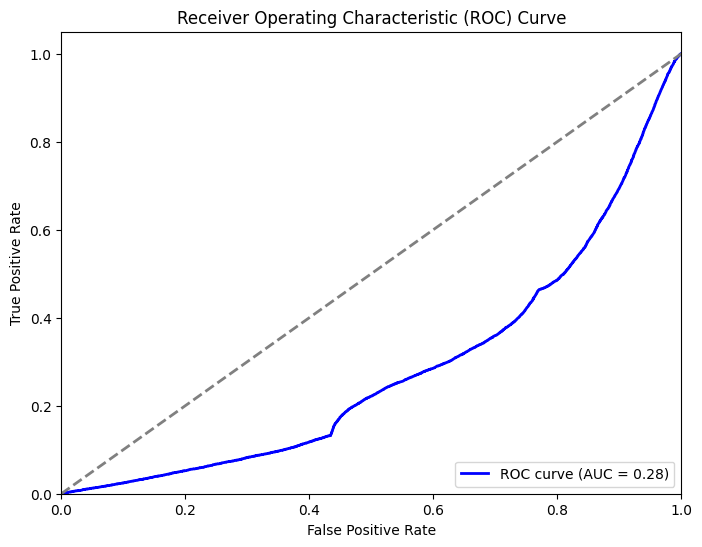

Model Performance:
Accuracy: 0.1319
Balanced Accuracy: 0.5000
Sensitivity: 0.0000
Specificity: 1.0000


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, balanced_accuracy_score
from sklearn.preprocessing import label_binarize

# Instantiate your BrainNet2D model
model = BrainNet2D(input_shape=(224, 224, 1), num_classes=3)


# Compile model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Get model predictions
y_true = test_generator.classes  # True labels
y_pred = model.predict(test_generator)  # Predicted probabilities
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert predictions to class labels

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print(f"Confusion Matrix:\n{cm}")

# Calculate Sensitivity (Recall) and Specificity
TP = cm[1, 1]  # True Positive
TN = cm[0, 0]  # True Negative
FP = cm[0, 1]  # False Positive
FN = cm[1, 0]  # False Negative

sensitivity = TP / (TP + FN)  # Recall or True Positive Rate
specificity = TN / (TN + FP)  # True Negative Rate

print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

# Balanced Accuracy
balanced_accuracy = (sensitivity + specificity) / 2
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")

# ROC Curve
# Binarize the true labels for multi-class ROC
y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
fpr, tpr, thresholds = roc_curve(y_true_bin.ravel(), y_pred.ravel())
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Print all metrics
print(f"Model Performance:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")


In [ ]:
# Define the Modified DenseNet121 model
def Modified_DenseNet121(input_shape=(224, 224, 1), num_classes=3):
    base_model = applications.DenseNet121(
        include_top=False,
        weights=None,  # No pretrained weights since input is grayscale
        input_shape=input_shape
    )

    # 🔴 Freeze the base model
    base_model.trainable = False

    # Feature extraction
    x = layers.GlobalAveragePooling2D()(base_model.output)

    # Two-stage linear transformation
    x = layers.Dense(x.shape[-1] // 2, activation="relu")(x)  # Reduce feature dimensions
    x = layers.Dense(num_classes, activation="softmax")(x)  # Class prediction

    model = models.Model(inputs=base_model.input, outputs=x)

    return model

# Create model
input_shape = (224, 224, 1)  # Grayscale MRI images
num_classes = 3  # Non Demented, Very Mild, Mild/Moderate
model = Modified_DenseNet121(input_shape, num_classes)

# Compile model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Summary
model.summary()


Model: "functional_44"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      3,136 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,557,571 (28.83 MB)

 Trainable params: 526,339 (2.01 MB)

 Non-trainable params: 7,031,232 (26.82 MB)

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dataset Paths
train_dir = "/root/split_data/Train"
val_dir = "/root/split_data/Validation"
test_dir = "/root/split_data/Test"

# Image preprocessing
train_datagen = ImageDataGenerator(rescale=1.0 / 255.0)
val_datagen = ImageDataGenerator(rescale=1.0 / 255.0)
test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

# Load images
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(224, 224), batch_size=32, color_mode="grayscale", class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=(224, 224), batch_size=32, color_mode="grayscale", class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(224, 224), batch_size=32, color_mode="grayscale", class_mode="categorical", shuffle=False
)

# Create & Compile Model
input_shape = (224, 224, 1)  # Grayscale images
num_classes = 3  # Non Demented, Very Mild, Mild/Moderate
model = Modified_DenseNet121(input_shape, num_classes)

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Train Model
history = model.fit(train_generator, epochs=10, validation_data=val_generator)

# Evaluate Model
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

# Save Model
model.save("densenet_ad_model.h5")


Found 87405 images belonging to 3 classes.
Found 18729 images belonging to 3 classes.
Found 18732 images belonging to 3 classes.
Epoch 1/10
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 316s 106ms/step - accuracy: 0.5681 - loss: 0.9192 - val_accuracy: 0.6817 - val_loss: 0.7596
Epoch 2/10
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 232s 85ms/step - accuracy: 0.6933 - loss: 0.7347 - val_accuracy: 0.7234 - val_loss: 0.6689
Epoch 3/10
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 232s 85ms/step - accuracy: 0.7226 - loss: 0.6716 - val_accuracy: 0.7401 - val_loss: 0.6404
Epoch 4/10
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 232s 85ms/step - accuracy: 0.7361 - loss: 0.6396 - val_accuracy: 0.7339 - val_loss: 0.6362
Epoch 5/10
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 232s 85ms/step - accuracy: 0.7375 - loss: 0.6270 - val_accuracy: 0.7453 - val_loss: 0.6079
Epoch 6/10
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 234s 86ms/step - accuracy: 0.7414 - loss: 0.6155 - val_accuracy: 0.7409 - val_loss: 0.6020
Epoch 7/10
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 233s 85ms/step - accuracy: 0.7

Test Loss: 0.5552055239677429, Test Accuracy: 0.7552850842475891


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications

# Define the Modified InceptionV3 model
def Modified_InceptionV3(input_shape=(299, 299, 1), num_classes=3):
    base_model = applications.InceptionV3(
        include_top=False,
        weights=None,  # No pretrained weights since input is grayscale
        input_shape=input_shape
    )
     #  Freeze the base model
    base_model.trainable = False

    # Feature extraction
    x = layers.GlobalAveragePooling2D()(base_model.output)

    # Dual-stage linear transformation
    x = layers.Dense(x.shape[-1] // 3, activation="relu")(x)  # Reduce feature dimensions by a third
    x = layers.Dense(num_classes, activation="softmax")(x)  # Class prediction

    model = models.Model(inputs=base_model.input, outputs=x)

    return model

# Create model
input_shape = (299, 299, 1)  # Grayscale MRI images
num_classes = 3  # Non Demented, Very Mild, Mild/Moderate
model = Modified_InceptionV3(input_shape, num_classes)

# Compile model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Summary
model.summary()


Model: "functional_46"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 149, 149,  │        288 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 149, 149,  │         96 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 73, 73,    │      5,120 │ max_pooling2d_10… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 23,201,675 (88.51 MB)

 Trainable params: 1,399,467 (5.34 MB)

 Non-trainable params: 21,802,208 (83.17 MB)

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths for the dataset
train_dir = "/root/split_data/Train"
val_dir = "/root/split_data/Validation"
test_dir = "/root/split_data/Test"

# Rescale pixel values
train_datagen = ImageDataGenerator(rescale=1.0/255.0)
val_datagen = ImageDataGenerator(rescale=1.0/255.0)

# Load training data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(299, 299),
    batch_size=32,
    color_mode="grayscale",
    class_mode="categorical",
    shuffle=True
)

# Load validation data
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(299, 299),
    batch_size=32,
    color_mode="grayscale",
    class_mode="categorical",
    shuffle=False
)

# Create model
input_shape = (299, 299, 1)
num_classes = 3
model = Modified_InceptionV3(input_shape, num_classes)

# Compile model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Train the model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

# Evaluate the model on the test set
test_datagen = ImageDataGenerator(rescale=1.0/255.0)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(299, 299),
    batch_size=32,
    color_mode="grayscale",
    class_mode="categorical",
    shuffle=False
)

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

Found 87405 images belonging to 3 classes.
Found 18729 images belonging to 3 classes.
Epoch 1/10
 591/2732 ━━━━━━━━━━━━━━━━━━━━ 3:53 109ms/step - accuracy: 0.5290 - loss: 0.9888

KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications

# Define the Modified VGG16 model
def Modified_VGG16(input_shape=(224, 224, 1), num_classes=3):
    base_model = applications.VGG16(
        include_top=False,
        weights=None,  # No pretrained weights since input is grayscale
        input_shape=input_shape
    )

    # Feature extraction
    x = layers.Flatten()(base_model.output)  # Flatten feature maps

    # **First Linear Layer (Halves dimensions)**
    x = layers.Dense(x.shape[-1] // 2, activation="relu")(x)

    # **Second Linear Layer (Maps to final output)**
    x = layers.Dense(x.shape[-1] // 2, activation="relu")(x)

    # **Final Classification Layer**
    x = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs=base_model.input, outputs=x)

    return model

# Create model
input_shape = (224, 224, 1)  # Grayscale MRI images
num_classes = 3  # Non Demented, Very Mild, Mild/Moderate
model = Modified_VGG16(input_shape, num_classes)

# Compile model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Model Summary
model.summary()

In [ ]:
# Load and preprocess image data
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set paths
train_dir = "/root/split_data/Train"
val_dir = "/root/split_data/Validation"
test_dir = "/root/split_data/Test"

# Data generators with normalization
train_datagen = ImageDataGenerator(rescale=1.0/255.0)
val_datagen = ImageDataGenerator(rescale=1.0/255.0)
test_datagen = ImageDataGenerator(rescale=1.0/255.0)

# Train generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    color_mode="grayscale",  # Grayscale input
    class_mode="categorical",
    shuffle=True
)

# Validation generator
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    color_mode="grayscale",
    class_mode="categorical",
    shuffle=False
)

# Create and compile the model (reuse from previous cell)
model = Modified_VGG16(input_shape=(224, 224, 1), num_classes=3)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Train the model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

# Evaluate the model on the test set
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    color_mode="grayscale",
    class_mode="categorical",
    shuffle=False
)

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

In [ ]:
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# Pick a layer name or index
layer_name = 'conv2_block3_out'  # Example for DenseNet121
intermediate_layer_model = Model(inputs=model.input,
                                 outputs=model.get_layer(layer_name).output)

# Get the activation for one image
image, _ = test_generator[0]  # Grab one batch
activation = intermediate_layer_model.predict(image[:1])

# Plot the feature maps
fig, axs = plt.subplots(4, 8, figsize=(15, 8))
for i in range(32):  # Show first 32 channels
    ax = axs[i // 8, i % 8]
    ax.imshow(activation[0, :, :, i], cmap='viridis')
    ax.axis('off')
plt.suptitle(f"Feature maps from layer: {layer_name}")
plt.tight_layout()
plt.show()

AttributeError: The layer sequential_3 has never been called and thus has no defined input.

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Example usage
img = test_generator[0][0][0:1]  # One image
heatmap = make_gradcam_heatmap(img, model, last_conv_layer_name="conv5_block16_2_conv")

# Display heatmap on top of original image
img = img[0].squeeze()
heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
overlay = heatmap_resized * 255
plt.imshow(img, cmap='gray')
plt.imshow(overlay, cmap='jet', alpha=0.5)
plt.title("Grad-CAM Visualization")
plt.axis("off")
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the Modified_DenseNet121 model
def Modified_DenseNet121(input_shape=(224, 224, 1), num_classes=3):
    # Create input
    inputs = layers.Input(shape=input_shape)

    # Duplicate the grayscale channel into 3 channels
    x = layers.Concatenate()([inputs, inputs, inputs])

    # Load pretrained DenseNet121
    base_model = applications.DenseNet121(
        include_top=False,
        weights="imagenet",  # Use pretrained ImageNet weights
        input_tensor=x
    )

    # Feature extraction
    x = layers.GlobalAveragePooling2D()(base_model.output)

    # Two-stage linear transformation
    x = layers.Dense(x.shape[-1] // 2, activation="relu")(x)  # Halve features
    x = layers.Dense(num_classes, activation="softmax")(x)    # Predict classes

    model = models.Model(inputs=inputs, outputs=x)

    return model

# Set paths for the data
train_dir = "/root/split_data/Train"
val_dir = "/root/split_data/Validation"
test_dir = "/root/split_data/Test"

# Data generators with normalization
train_datagen = ImageDataGenerator(rescale=1.0/255.0)
val_datagen = ImageDataGenerator(rescale=1.0/255.0)
test_datagen = ImageDataGenerator(rescale=1.0/255.0)

# Train generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    color_mode="grayscale",  # Grayscale input
    class_mode="categorical",
    shuffle=True
)

# Validation generator
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    color_mode="grayscale",
    class_mode="categorical",
    shuffle=False
)

# Test generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    color_mode="grayscale",
    class_mode="categorical",
    shuffle=False
)

# Instantiate the model
model = Modified_DenseNet121(input_shape=(224, 224, 1), num_classes=3)

# Freeze base model (except the last few layers)
for layer in model.layers[:-3]:  # Keep last few layers trainable
    layer.trainable = False

# Compile the model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Train initial classifier
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

# Fine-tune: Unfreeze the entire base model
for layer in model.layers:
    layer.trainable = True

# Recompile with a lower learning rate
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss="categorical_crossentropy", metrics=["accuracy"])

# Continue training (fine-tuning)
fine_tune_epochs = 10
total_epochs = 10 + fine_tune_epochs

history_finetune = model.fit(
    train_generator,
    epochs=total_epochs,
    initial_epoch=10,
    validation_data=val_generator
)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")


Found 87405 images belonging to 3 classes.
Found 18729 images belonging to 3 classes.
Found 18732 images belonging to 3 classes.
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2732/2732 ━━━━━━━━━━━━━━━━━━━━ 283s 96ms/step - accuracy: 0.7563 - loss: 0.5690 - val_accuracy: 0.8392 - val_loss: 0.3710
Epoch 2/10
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 290s 87ms/step - accuracy: 0.8425 - loss: 0.3654 - val_accuracy: 0.8734 - val_loss: 0.2994
Epoch 3/10
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 238s 87ms/step - accuracy: 0.8786 - loss: 0.2911 - val_accuracy: 0.8740 - val_loss: 0.2953
Epoch 4/10
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 237s 87ms/step - accuracy: 0.9071 - loss: 0.2281 - val_accuracy: 0.8866 - val_loss: 0.2919
Epoch 5/10
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 238s 87ms/step - accuracy: 0.9241 - loss: 0.1904 - val_accuracy: 0.9292 - val_loss: 0.1763
Epoch 6/10
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 238s 87ms/step - accuracy: 0.9352 - loss: 0.1624 - val_accuracy: 0.8999 - val_loss: 0.2622
Epoch 7/10
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 263s 87ms/step - accuracy: 0.9442 - loss: 0.1436 - val_accuracy: 0.9345 - val_loss: 0.1628
Epoch 8/10
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 262s 88ms/step - accuracy: 0.9493 - lo

KeyboardInterrupt: 

586/586 ━━━━━━━━━━━━━━━━━━━━ 59s 83ms/step - accuracy: 0.8023 - loss: 0.8534
Test Loss: 0.5917, Test Accuracy: 0.8538
586/586 ━━━━━━━━━━━━━━━━━━━━ 61s 88ms/step
Confusion Matrix:
[[1474  148  849]
 [ 108 9600  376]
 [ 606  651 4920]]
Sensitivity: 0.9889
Specificity: 0.9088
Balanced Accuracy: 0.9488


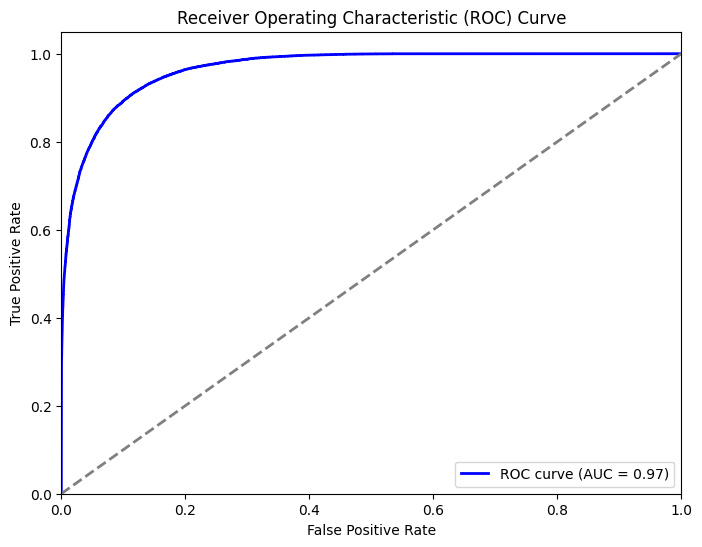

Model Performance:
Accuracy: 0.8538
Balanced Accuracy: 0.9488
Sensitivity: 0.9889
Specificity: 0.9088


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, balanced_accuracy_score
from sklearn.preprocessing import label_binarize



# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Get model predictions
y_true = test_generator.classes  # True labels
y_pred = model.predict(test_generator)  # Predicted probabilities
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert predictions to class labels

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print(f"Confusion Matrix:\n{cm}")

# Calculate Sensitivity (Recall) and Specificity
TP = cm[1, 1]  # True Positive
TN = cm[0, 0]  # True Negative
FP = cm[0, 1]  # False Positive
FN = cm[1, 0]  # False Negative

sensitivity = TP / (TP + FN)  # Recall or True Positive Rate
specificity = TN / (TN + FP)  # True Negative Rate

print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

# Balanced Accuracy
balanced_accuracy = (sensitivity + specificity) / 2
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")

# ROC Curve
# Binarize the true labels for multi-class ROC
y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
fpr, tpr, thresholds = roc_curve(y_true_bin.ravel(), y_pred.ravel())
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Print all metrics
print(f"Model Performance:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the Modified Convolutional Block for 3D
def ModifiedConvBlock3D(filters, kernel_size=3, pool_size=2):
    block = models.Sequential()
    block.add(layers.Conv3D(filters, kernel_size, padding="same"))
    block.add(layers.BatchNormalization())
    block.add(layers.Activation("relu"))
    block.add(layers.MaxPooling3D(pool_size=pool_size))
    return block

# Define the Modified BrainNet3D model
def Modified_BrainNet3D(input_shape=(64, 64, 64, 1), num_classes=3):
    inputs = layers.Input(shape=input_shape)

    x = inputs
    # Add 7 ModifiedConvBlock3D layers
    filter_sizes = [8, 16, 32, 64, 128, 256, 512]
    for filters in filter_sizes:
        x = ModifiedConvBlock3D(filters)(x)

    # Dropout instead of GAP
    x = layers.Dropout(0.3)(x)
    x = layers.Flatten()(x)

    # Linear + ReLU x3
    for _ in range(3):
        x = layers.Dense(512)(x)
        x = layers.ReLU()(x)

    # Final classification layer
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    return model

# Instantiate the model
model = Modified_BrainNet3D(input_shape=(64, 64, 64, 1), num_classes=3)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()
